/home/zy/anaconda3/envs/pytorch/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


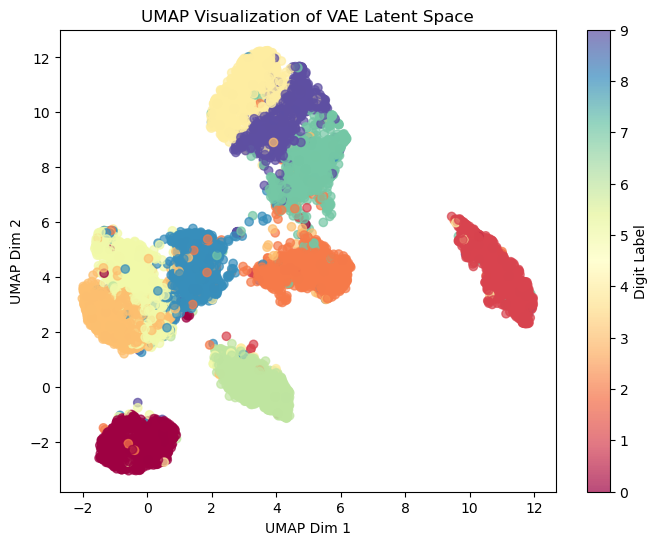

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import umap
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

'''
# 假设 VAE 已经训练好，并且能够提取潜在向量
class VAE(torch.nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(28*28, 400),
            torch.nn.ReLU(),
            torch.nn.Linear(400, latent_dim * 2)  # 输出均值 mu 和 logvar
        )
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def encode(self, x):
        h = self.encoder(x)
        mu, logvar = h.chunk(2, dim=1)
        z = self.reparameterize(mu, logvar)
        return z
'''        

# 定义 VAE
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()
        # 编码器
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2_mu = nn.Linear(hidden_dim, latent_dim)  # 均值
        self.fc2_logvar = nn.Linear(hidden_dim, latent_dim)  # 方差

        # 解码器
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc2_mu(h)
        logvar = self.fc2_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))  # 输出为 0-1 之间

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar
        
# 载入训练好的 VAE 模型
latent_dim = 20  # 设定潜在空间维度（可根据需要调整）
vae = VAE(latent_dim=latent_dim)
vae.load_state_dict(torch.load("vae_model.pth"))  # 载入已训练的模型
vae.eval()

# 载入 MNIST 数据集
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
mnist = datasets.MNIST(root="./data", train=False, transform=transform, download=True)
dataloader = DataLoader(mnist, batch_size=1000, shuffle=False)

# 获取潜在空间表示
latent_vectors = []
labels = []

with torch.no_grad():
    for images, lbls in dataloader:
        images = images.view(images.size(0), -1)  # 展平成一维向量
        mu, logvar = vae.encode(images)  # 获取均值和方差
        z = vae.reparameterize(mu, logvar)  # 进行 reparameterization 采样
        latent_vectors.append(z.numpy())  # 转换为 NumPy 数组
        labels.append(lbls.numpy())  # 记录对应标签

latent_vectors = np.vstack(latent_vectors)  # 将所有批次的数据合并
labels = np.hstack(labels)

# 使用 UMAP 降维到 2D
umap_model = umap.UMAP(n_components=2, random_state=42)
latent_2d = umap_model.fit_transform(latent_vectors)

# 绘制 UMAP 降维后的数据
plt.figure(figsize=(8, 6))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=labels, cmap='Spectral', alpha=0.7)
plt.colorbar(scatter, label="Digit Label")
plt.xlabel("UMAP Dim 1")
plt.ylabel("UMAP Dim 2")
plt.title("UMAP Visualization of VAE Latent Space")
plt.show()
